# CBVD-5 Dataset Analysis

**Dataset:** Cattle Behavior Video Dataset – 5 classes (CBVD-5)  
**Notebook:** `notebooks/dataset_analysis/analysis_cbvd5.ipynb`  
**Output:** `results/analysis/cbvd5_summary.json`

Derives all statistics from `data/raw/cbvd5/` only. No pipeline outputs are read.


In [1]:
import sys, os, re, json, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

# Repo root on sys.path so we can import src/
REPO_ROOT = Path("../..")
sys.path.insert(0, str(REPO_ROOT))
from src.data.label_utils import (
    LABEL_NAMES,
    _CBVD5_ACTION_MAP,
    _CBVD5_PRIORITY,
    cbvd5_actions_to_label,
)

RAW = REPO_ROOT / "data" / "raw" / "cbvd5"
RESULTS_DIR = REPO_ROOT / "results" / "analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("RAW path:", RAW.resolve())
print("Contents:", [p.name for p in RAW.iterdir()])

RAW path: /home/sakif/TXST/Thesis/cattle-vision-framework/data/raw/cbvd5
Contents: ['CBVD-5.csv', 'labelframes', 'minilabelframes', 'miniannotations', 'videos', 'annotations', 'videos_add', 'rawframes_mini', 'labelframes_add']


---

## 1. Dataset Overview

**Origin:** CBVD-5 is an indoor dairy-cattle surveillance dataset collected at a commercial barn. Videos are recorded from ceiling-mounted fixed cameras.

**Paper:** _"A Multi-behavior Recognition System for Dairy Cattle Based on Deep Learning"_ (CBVD-5 release). The dataset was adapted from the AVA video annotation format (used in human action recognition) to cattle behavior.

**License:** Research use only (no explicit open license in release).

**Annotation format:** Two parallel formats ship with the dataset:

- **VIA CSV** (`CBVD-5.csv`) — VGG Image Annotator export; bounding boxes + multi-label behavior attributes on extracted frames.
- **AVA CSV** (`annotations/ava_{train,val}_v2.1.csv`) — AVA-format rows: `video_id, timestamp, x1, y1, x2, y2, action_id, entity_id`. Coordinates are normalized [0,1]. Action IDs 1–5.

**5-class behavior taxonomy (raw → canonical):**

| AVA action_id | CBVD-5 label   | Canonical ID | Canonical name |
| ------------- | -------------- | ------------ | -------------- |
| 1             | stand          | 0            | Standing       |
| 2             | lying down     | 1            | Lying          |
| 3             | foraging       | 2            | Foraging       |
| 4             | drinking water | 3            | Drinking       |
| 5             | rumination     | 4            | Ruminating     |

**Role in thesis pipeline:**

- **Training dataset** for behavior classifier (VideoMAE configs 1, 4, 5)
- **In-domain evaluation** for config 1 (CBVD-5 val set used as test — no separate test labels released)
- **Cross-domain source** for config 4 (trained on CBVD-5, evaluated on CVB)


---

## 2. Data Inventory


In [2]:
videos_dir = RAW / "videos" / "videos"
frames_dir = RAW / "labelframes" / "labelframes"
via_csv_path = RAW / "CBVD-5.csv"
ava_train_path = RAW / "annotations" / "ava_train_v2.1.csv"
ava_val_path = RAW / "annotations" / "ava_val_v2.1.csv"

videos = sorted(videos_dir.glob("*.mp4"))
frames = sorted(frames_dir.glob("*.jpg"))

print(f"Videos (.mp4):       {len(videos):>6}")
print(f"Labelframes (.jpg):  {len(frames):>6}")
print(f"VIA CSV size:        {via_csv_path.stat().st_size / 1024 / 1024:.1f} MB")
print(f"AVA train rows:      {sum(1 for _ in open(ava_train_path)):>6}")
print(f"AVA val rows:        {sum(1 for _ in open(ava_val_path)):>6}")

Videos (.mp4):          687
Labelframes (.jpg):    4122
VIA CSV size:        2.3 MB
AVA train rows:       34102
AVA val rows:          3761


In [3]:
# Load AVA CSVs
AVA_COLS = ["video_id", "timestamp", "x1", "y1", "x2", "y2", "action_id", "entity_id"]
ava_train = pd.read_csv(ava_train_path, header=None, names=AVA_COLS)
ava_val = pd.read_csv(ava_val_path, header=None, names=AVA_COLS)

# Cast integer columns
for df in [ava_train, ava_val]:
    df["video_id"] = df["video_id"].astype(int)
    df["action_id"] = df["action_id"].astype(int)
    df["entity_id"] = df["entity_id"].astype(int)

print("=== AVA TRAIN ===")
print(f"  Rows:           {len(ava_train):>6}")
print(f"  Unique videos:  {ava_train.video_id.nunique():>6}")
print(f"  Unique entities:{ava_train.entity_id.nunique():>6}")
print(f"  Timestamps:     {ava_train.timestamp.nunique():>6} unique")

print("\n=== AVA VAL ===")
print(f"  Rows:           {len(ava_val):>6}")
print(f"  Unique videos:  {ava_val.video_id.nunique():>6}")
print(f"  Unique entities:{ava_val.entity_id.nunique():>6}")

print(
    "\nNote: CBVD-5 has no separate test set. Val split is used as test in this thesis."
)

=== AVA TRAIN ===
  Rows:            34102
  Unique videos:     492
  Unique entities:     1
  Timestamps:          6 unique

=== AVA VAL ===
  Rows:             3761
  Unique videos:      50
  Unique entities:     1

Note: CBVD-5 has no separate test set. Val split is used as test in this thesis.


---

## 3. Sample Image Visualization


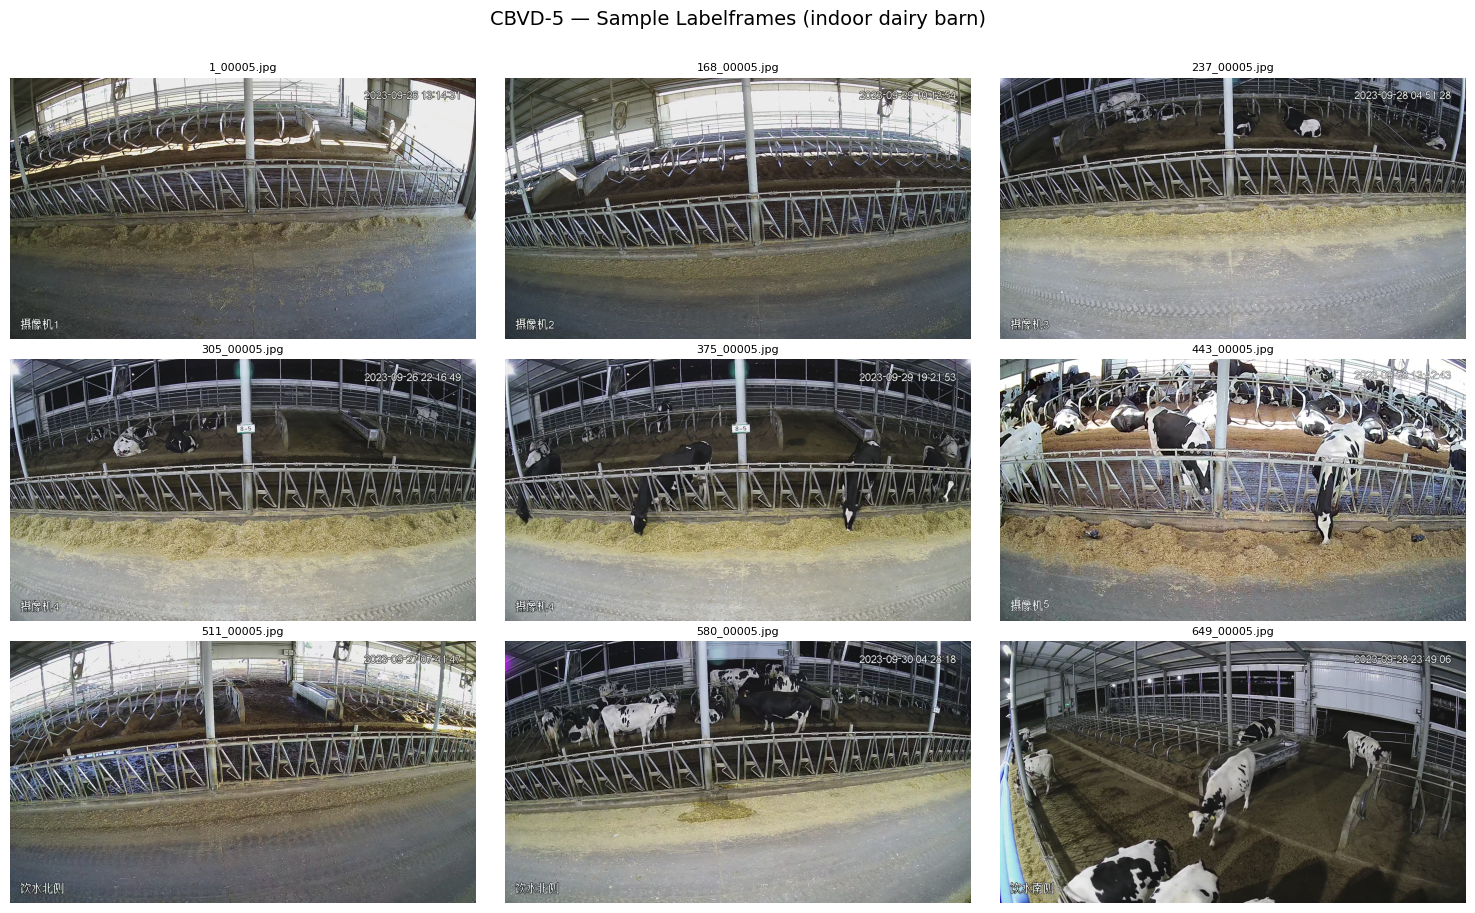

Saved: results/analysis/cbvd5_sample_frames.png


In [4]:
# Pick 9 evenly-spaced frames from different videos
# Frame filenames are {video_id}_{frame_num}.jpg — pick from varied video IDs
video_ids_in_frames = sorted(set(f.stem.split("_")[0] for f in frames))
step = max(1, len(video_ids_in_frames) // 9)
sample_vids = video_ids_in_frames[::step][:9]

sample_frames = []
for vid in sample_vids:
    candidates = [f for f in frames if f.stem.startswith(vid + "_")]
    if candidates:
        sample_frames.append(candidates[len(candidates) // 2])  # middle frame

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
fig.suptitle("CBVD-5 — Sample Labelframes (indoor dairy barn)", fontsize=14, y=1.01)

for ax, fpath in zip(axes.flat, sample_frames):
    img = Image.open(fpath)
    ax.imshow(img)
    ax.set_title(fpath.name, fontsize=8)
    ax.axis("off")

for ax in axes.flat[len(sample_frames) :]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cbvd5_sample_frames.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: results/analysis/cbvd5_sample_frames.png")

---

## 4. Annotation Format


In [5]:
# --- VIA CSV format ---
print("=== VIA CSV (CBVD-5.csv) ===")
print("Comment header lines (first 10):")
with open(via_csv_path) as f:
    for i, line in enumerate(f):
        if line.startswith("#"):
            print(f"  {line.rstrip()}")
        else:
            break

print("\nFirst data row:")
with open(via_csv_path) as f:
    data_rows = [l for l in f if not l.startswith("#")]

# VIA rows: metadata_id, file_list, flags, temporal_coords, spatial_coords, metadata
sample = data_rows[0].strip()
parts = sample.split(",", 5)
labels = [
    "metadata_id",
    "file_list",
    "flags",
    "temporal_coordinates",
    "spatial_coordinates",
    "metadata",
]
for label, val in zip(labels, parts):
    print(f"  {label:<24} = {val}")

print()
print(
    "spatial_coordinates format: [shape_id, x, y, width, height]  (shape_id=2 → rectangle)"
)
print(
    "metadata format: {'1': 'option_ids'}  where option_ids are comma-separated action IDs (0-indexed in VIA → map to AVA 1-indexed)"
)
print("\nNote: VIA attribute options 0–4 correspond to AVA action_ids 1–5")

=== VIA CSV (CBVD-5.csv) ===
Comment header lines (first 10):
  # Exported using VGG Image Annotator (http://www.robots.ox.ac.uk/~vgg/software/via)
  # Notes:
  # - spatial_coordinates of [2,10,20,50,80] denotes a rectangle (shape_id=2) of size 50x80 placed at (10,20)
  # - temporal coordinate of [1.349,2.741] denotes a temporal segment from time 1.346 sec. to 2.741 sec.
  # - temporal coordinate of [4.633] denotes a still video frame at 4.633 sec.
  # - metadata of {""1"":""3""} indicates attribute with id "1" set to an attribute option with id "3"
  # SHAPE_ID = {"POINT":1,"RECTANGLE":2,"CIRCLE":3,"ELLIPSE":4,"LINE":5,"POLYLINE":6,"POLYGON":7,"EXTREME_RECTANGLE":8,"EXTREME_CIRCLE":9}
  # FLAG_ID = {"RESERVED_FOR_FUTURE":1}
  # ATTRIBUTE = {"1":{"aname":"cow","anchor_id":"FILE1_Z0_XY1","type":2,"desc":"","options":{"0":"stand","1":"lying down","2":"foraging","3":"drinking water","4":"rumination"},"default_option_id":""}}
  # CSV_HEADER = metadata_id,file_list,flags,temporal_coordinate

In [6]:
# --- AVA CSV format ---
print("=== AVA CSV (ava_train_v2.1.csv) ===")
print("Columns: video_id, timestamp, x1, y1, x2, y2, action_id, entity_id")
print("         (no header row in file; columns inferred from AVA spec)")
print()
print("Sample row (first 3 rows for video 618, timestamp 2):")
sample_ava = ava_train[ava_train.video_id == 618].head(3)
print(sample_ava.to_string(index=False))
print()
print("Coordinate convention: normalized [0, 1] relative to frame dimensions")
print(
    "Multi-label: a single (video_id, timestamp, entity_id) may have multiple rows with different action_ids"
)

=== AVA CSV (ava_train_v2.1.csv) ===
Columns: video_id, timestamp, x1, y1, x2, y2, action_id, entity_id
         (no header row in file; columns inferred from AVA spec)

Sample row (first 3 rows for video 618, timestamp 2):
 video_id  timestamp       x1       y1       x2       y2  action_id  entity_id
      618          2 0.457093 0.359019 0.624562 0.683012          1          1
      618          2 0.457093 0.359019 0.624562 0.683012          5          1
      618          2 0.791046 0.488617 0.899409 0.831874          2          1

Coordinate convention: normalized [0, 1] relative to frame dimensions
Multi-label: a single (video_id, timestamp, entity_id) may have multiple rows with different action_ids


---

## 5. Class Distribution


In [7]:
# Count raw action_id occurrences in AVA (each row = one action instance)
train_counts = ava_train.action_id.value_counts().sort_index()
val_counts = ava_val.action_id.value_counts().sort_index()

AVA_LABEL = {
    1: "stand",
    2: "lying down",
    3: "foraging",
    4: "drinking water",
    5: "rumination",
}
CANONICAL = {
    1: "Standing (0)",
    2: "Lying (1)",
    3: "Foraging (2)",
    4: "Drinking (3)",
    5: "Ruminating (4)",
}

print("Action distribution in AVA CSVs (raw annotation rows):")
print(
    f"{'action_id':<12} {'CBVD-5 label':<18} {'Canonical':<16} {'Train':>8} {'Val':>8} {'Total':>8}"
)
print("-" * 72)
totals = {}
for aid in range(1, 6):
    tr = train_counts.get(aid, 0)
    vl = val_counts.get(aid, 0)
    totals[aid] = tr + vl
    print(
        f"{aid:<12} {AVA_LABEL[aid]:<18} {CANONICAL[aid]:<16} {tr:>8,} {vl:>8,} {tr+vl:>8,}"
    )
print("-" * 72)
print(
    f"{'TOTAL':<12} {'':<18} {'':<16} {len(ava_train):>8,} {len(ava_val):>8,} {len(ava_train)+len(ava_val):>8,}"
)

Action distribution in AVA CSVs (raw annotation rows):
action_id    CBVD-5 label       Canonical           Train      Val    Total
------------------------------------------------------------------------
1            stand              Standing (0)       14,310    1,513   15,823
2            lying down         Lying (1)           8,485    1,021    9,506
3            foraging           Foraging (2)        4,920      791    5,711
4            drinking water     Drinking (3)          691       53      744
5            rumination         Ruminating (4)      5,696      383    6,079
------------------------------------------------------------------------
TOTAL                                              34,102    3,761   37,863


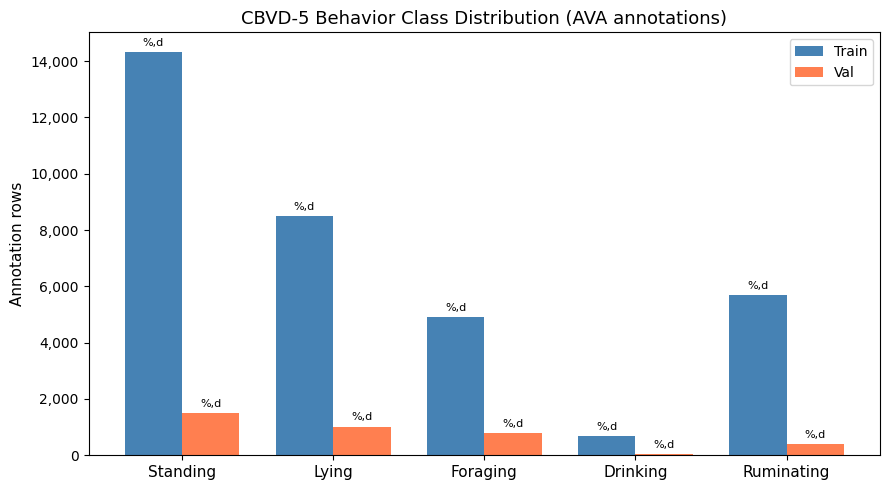

Saved: results/analysis/cbvd5_class_distribution.png


In [8]:
# Map to canonical IDs for the bar chart
canonical_train = collections.Counter()
canonical_val = collections.Counter()
for _, row in ava_train.iterrows():
    cid = _CBVD5_ACTION_MAP[row.action_id]
    canonical_train[cid] += 1
for _, row in ava_val.iterrows():
    cid = _CBVD5_ACTION_MAP[row.action_id]
    canonical_val[cid] += 1

label_ids = sorted(canonical_train.keys())
label_names = [LABEL_NAMES[i] for i in label_ids]
train_vals = [canonical_train[i] for i in label_ids]
val_vals = [canonical_val[i] for i in label_ids]

x = np.arange(len(label_ids))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width / 2, train_vals, width, label="Train", color="steelblue")
bars2 = ax.bar(x + width / 2, val_vals, width, label="Val", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(label_names, fontsize=11)
ax.set_ylabel("Annotation rows", fontsize=11)
ax.set_title("CBVD-5 Behavior Class Distribution (AVA annotations)", fontsize=13)
ax.legend()
ax.bar_label(bars1, fmt="%,d", fontsize=8, padding=3)
ax.bar_label(bars2, fmt="%,d", fontsize=8, padding=3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cbvd5_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/analysis/cbvd5_class_distribution.png")

**Observations:**

- Standing is the dominant class, reflecting typical barn occupancy patterns.
- Drinking is the rarest class — cows visit the water trough infrequently.
- Class imbalance is significant: Standing is ~3× more common than Ruminating and ~20× more common than Drinking.
- This imbalance motivates the class-weighted loss used in VideoMAE training (see `src/behavior/dataset.py`).


---

## 6. Resolution & Quality


In [10]:
# Sample 30 frames to check resolution consistency and detect any corrupt files
step = max(1, len(frames) // 30)
sample_check = frames[::step][:30]

resolutions = collections.Counter()
corrupt = []
for fpath in sample_check:
    try:
        img = Image.open(fpath)
        img.verify()
        resolutions[img.size] += 1
    except Exception as e:
        corrupt.append((fpath.name, str(e)))

print(f"Checked {len(sample_check)} frames (sampled from {len(frames)} total)")
print(f"Resolutions found: {dict(resolutions)}")
print(f"Corrupt files: {len(corrupt)}")
if corrupt:
    for name, err in corrupt:
        print(f"  ⚠️  {name}: {err}")

dominant_res = resolutions.most_common(1)[0][0]
print(f"Dominant resolution: {dominant_res[0]}×{dominant_res[1]} px")

# FPS and duration from one video using OpenCV (ffprobe not required)
import cv2

sample_video = videos[0]
cap = cv2.VideoCapture(str(sample_video))
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
duration = n_frames / fps if fps > 0 else 0
cap.release()
print(f"Sample video ({sample_video.name}):")
print(f"  Frame rate: {fps:.2f} fps")
print(f"  Duration:   {duration:.1f} sec  ({int(n_frames)} frames)")

Checked 30 frames (sampled from 4122 total)
Resolutions found: {(1920, 1080): 30}
Corrupt files: 0
Dominant resolution: 1920×1080 px
Sample video (1.mp4):
  Frame rate: 25.00 fps
  Duration:   10.0 sec  (250 frames)


---

## 7. Label Mapping to 7-class Taxonomy


In [11]:
print("CBVD-5 → 7-class canonical taxonomy mapping")
print("=" * 60)
print(
    f"{'AVA action_id':<16} {'CBVD-5 label':<20} {'Canonical ID':<14} {'Canonical name'}"
)
print("-" * 60)
cbvd5_raw = {
    1: "stand",
    2: "lying down",
    3: "foraging",
    4: "drinking water",
    5: "rumination",
}
for action_id, raw_label in cbvd5_raw.items():
    cid = _CBVD5_ACTION_MAP[action_id]
    print(f"{action_id:<16} {raw_label:<20} {cid:<14} {LABEL_NAMES[cid]}")
print()
print("Classes NOT present in CBVD-5 (canonical IDs 5 and 6):")
print("  5 — Grooming   (CVB only)")
print("  6 — Other      (CVB only)")
print()
print("Priority rule for multi-label AVA rows (highest priority wins):")
priority_order = [cbvd5_raw[a] for a in _CBVD5_PRIORITY]
print("  Lowest → Highest:", " > ".join(priority_order))
print("  Implemented in: src/data/label_utils.py :: cbvd5_actions_to_label()")

CBVD-5 → 7-class canonical taxonomy mapping
AVA action_id    CBVD-5 label         Canonical ID   Canonical name
------------------------------------------------------------
1                stand                0              Standing
2                lying down           1              Lying
3                foraging             2              Foraging
4                drinking water       3              Drinking
5                rumination           4              Ruminating

Classes NOT present in CBVD-5 (canonical IDs 5 and 6):
  5 — Grooming   (CVB only)
  6 — Other      (CVB only)

Priority rule for multi-label AVA rows (highest priority wins):
  Lowest → Highest: stand > lying down > rumination > foraging > drinking water
  Implemented in: src/data/label_utils.py :: cbvd5_actions_to_label()


---

## 8. Preprocessing Gap Analysis


In [12]:
print("Preprocessing steps required before CBVD-5 enters the pipeline:")
print()
print("1. Frame extraction (script 02_prepare_cbvd5.sh)")
print("   - Reads labelframe filenames from CBVD-5.csv")
print("   - Copies/links frames into data/processed/detection/cbvd5/images/")
print("   - Converts VIA bounding boxes + action labels to YOLO-format .txt files")
print()
print("2. AVA multi-label collapse (src/data/label_utils.py)")
print("   - Multiple action_id rows per (video, timestamp, entity) are collapsed")
print("     to a single canonical label via the priority rule")
print()
print("3. Train/val split")
print("   - Train: videos appearing in ava_train_v2.1.csv (492 unique video IDs)")
print("   - Val:   videos appearing in ava_val_v2.1.csv   (50 unique video IDs)")
print("   - ⚠️  No test split: CBVD-5 did not release test labels.")
print("          Val split is used as test throughout this thesis.")
print()
print("4. Tubelet generation (script 09_generate_tubelets.sh)")
print("   - 16-frame clips, stride 4, 224×224 px (after detection + tracking)")
print()

# Check for any VIA-referenced frames missing on disk
via_files = set()
with open(via_csv_path) as f:
    for line in f:
        if line.startswith("#"):
            continue
        m = re.search(r'\[""([^"]+\.jpg)""\]', line)
        if m:
            via_files.add(m.group(1))

on_disk = set(f.name for f in frames)
missing = via_files - on_disk
extra = on_disk - via_files

print(f"VIA CSV references {len(via_files):,} unique frame filenames")
print(f"Frames on disk:     {len(on_disk):,}")
print(f"Referenced but missing on disk: {len(missing)}")
print(f"On disk but not in VIA CSV:     {len(extra)}")
if missing:
    print("  ⚠️  Sample missing:", sorted(missing)[:5])
if extra:
    print("  ℹ️  Sample extra:", sorted(extra)[:5])

Preprocessing steps required before CBVD-5 enters the pipeline:

1. Frame extraction (script 02_prepare_cbvd5.sh)
   - Reads labelframe filenames from CBVD-5.csv
   - Copies/links frames into data/processed/detection/cbvd5/images/
   - Converts VIA bounding boxes + action labels to YOLO-format .txt files

2. AVA multi-label collapse (src/data/label_utils.py)
   - Multiple action_id rows per (video, timestamp, entity) are collapsed
     to a single canonical label via the priority rule

3. Train/val split
   - Train: videos appearing in ava_train_v2.1.csv (492 unique video IDs)
   - Val:   videos appearing in ava_val_v2.1.csv   (50 unique video IDs)
   - ⚠️  No test split: CBVD-5 did not release test labels.
          Val split is used as test throughout this thesis.

4. Tubelet generation (script 09_generate_tubelets.sh)
   - 16-frame clips, stride 4, 224×224 px (after detection + tracking)

VIA CSV references 3,199 unique frame filenames
Frames on disk:     4,122
Referenced but missin

---

## 9. Summary JSON + Self-Consistency Check


In [13]:
# Build class_distribution from canonical IDs across both splits
class_dist = {}
for aid, cid in _CBVD5_ACTION_MAP.items():
    count = int(train_counts.get(aid, 0) + val_counts.get(aid, 0))
    key = str(cid)
    class_dist[key] = class_dist.get(key, 0) + count

summary = {
    "dataset": "cbvd5",
    "total_images_or_frames": len(frames),
    "total_annotations": int(len(ava_train) + len(ava_val)),
    "splits": {
        "train": int(ava_train.video_id.nunique()),
        "val": int(ava_val.video_id.nunique()),
        "test": 0,
    },
    "class_distribution": {k: int(v) for k, v in sorted(class_dist.items())},
    "resolution": {"width": dominant_res[0], "height": dominant_res[1]},
    "has_behavior_labels": True,
    "evaluation_scope": ["behavior_f1", "in_domain", "cross_domain_source"],
}

# Schema validation
required_keys = [
    "dataset",
    "total_images_or_frames",
    "total_annotations",
    "splits",
    "class_distribution",
    "resolution",
    "has_behavior_labels",
    "evaluation_scope",
]
missing_keys = [k for k in required_keys if k not in summary]
assert not missing_keys, f"Missing schema keys: {missing_keys}"

non_int = {
    k: v
    for k, v in summary["class_distribution"].items()
    if not isinstance(v, int) or v == 0
}
assert not non_int, f"class_distribution has zero or non-int values: {non_int}"

out_path = RESULTS_DIR / "cbvd5_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Summary JSON:")
print(json.dumps(summary, indent=2))
print(f"\n✅ Saved: {out_path}")

Summary JSON:
{
  "dataset": "cbvd5",
  "total_images_or_frames": 4122,
  "total_annotations": 37863,
  "splits": {
    "train": 492,
    "val": 50,
    "test": 0
  },
  "class_distribution": {
    "0": 15823,
    "1": 9506,
    "2": 5711,
    "3": 744,
    "4": 6079
  },
  "resolution": {
    "width": 1920,
    "height": 1080
  },
  "has_behavior_labels": true,
  "evaluation_scope": [
    "behavior_f1",
    "in_domain",
    "cross_domain_source"
  ]
}

✅ Saved: ../../results/analysis/cbvd5_summary.json


In [14]:
# Self-consistency check against known dataset statistics
# Reference numbers from the CBVD-5 paper and pipeline logs
print("Self-consistency check:")
print("=" * 55)

checks = [
    ("Total videos", len(videos), 687, "== 687 (paper)"),
    ("Train annotation rows", len(ava_train), 34102, "== 34102"),
    ("Val annotation rows", len(ava_val), 3761, "== 3761"),
    ("Unique train videos", ava_train.video_id.nunique(), 492, "== 492"),
    ("Unique val videos", ava_val.video_id.nunique(), 50, "== 50"),
    ("Labelframes on disk", len(frames), 4122, "== 4122"),
    ("Frame resolution W", dominant_res[0], 1920, "== 1920"),
    ("Frame resolution H", dominant_res[1], 1080, "== 1080"),
]

all_ok = True
for name, computed, expected, note in checks:
    ok = computed == expected
    status = "✅" if ok else "⚠️ "
    if not ok:
        all_ok = False
    print(f"{status} {name:<30} computed={computed:>6}  expected={expected:>6}  {note}")

print()
if all_ok:
    print("✅ All checks passed.")
else:
    print("⚠️  Some checks failed — review the values above.")

Self-consistency check:
✅ Total videos                   computed=   687  expected=   687  == 687 (paper)
✅ Train annotation rows          computed= 34102  expected= 34102  == 34102
✅ Val annotation rows            computed=  3761  expected=  3761  == 3761
✅ Unique train videos            computed=   492  expected=   492  == 492
✅ Unique val videos              computed=    50  expected=    50  == 50
✅ Labelframes on disk            computed=  4122  expected=  4122  == 4122
✅ Frame resolution W             computed=  1920  expected=  1920  == 1920
✅ Frame resolution H             computed=  1080  expected=  1080  == 1080

✅ All checks passed.
